# HMM / EM 실습: 한국어 품사 태깅 (POS Tagging)

## 실습 목표
1. **HMM(Hidden Markov Model)** 의 세 가지 핵심 문제 중 두 가지를 구현
   - Decoding: **Viterbi 알고리즘**
   - Learning: **Baum-Welch 알고리즘 (= HMM에 대한 EM)**
2. 한국어 형태소 분석 결과(세종 태그셋 기반)를 실습 데이터로 사용

## 학습 데이터셋
문어체 예문을 **Komoran**(세종 태그셋 기반 형태소 분석기)으로 자동 태깅한 뒤,
학습 편의를 위해 태그를 아래 8개 범주로 단순화

| 단순 태그 | 의미 | 원본 세종 태그 예시 |
|---|---|---|
| N | 체언(명사류) | NNG, NNP, NNB, NP, NR |
| V | 동사 | VV, VX |
| A | 형용사/지정사 | VA, VCP, VCN |
| M | 수식언(관형사/부사) | MM, MAG, MAJ |
| J | 조사 | JKS, JKO, JX 등 |
| E | 어미 | EP, EF, EC, ETN, ETM |
| IC | 감탄사 | IC |
| X | 접사/어근 | XPN, XSN, XSV 등 |
| S | 기호/숫자 | SF, SN 등 |


## 0. 환경 준비

In [ ]:
# Colab 환경 준비 (이미 설치되어 있을 수 있음)
# !pip install konlpy -q
# !apt-get install -y default-jdk -q > /dev/null

import json
import math
import random
from collections import defaultdict, Counter

random.seed(0)


## 1. 데이터 준비: 예문 자동 태깅

Komoran으로 예문을 형태소 분석하고 단순화 태그로 전처리

In [3]:
from konlpy.tag import Komoran

TAG_MAP = {
    "NNG": "N", "NNP": "N", "NNB": "N", "NP": "N", "NR": "N",
    "VV": "V", "VX": "V",
    "VA": "A", "VCP": "A", "VCN": "A",
    "MM": "M", "MAG": "M", "MAJ": "M",
    "JKS": "J", "JKC": "J", "JKG": "J", "JKO": "J", "JKB": "J",
    "JKV": "J", "JKQ": "J", "JX": "J", "JC": "J",
    "EP": "E", "EF": "E", "EC": "E", "ETN": "E", "ETM": "E",
    "IC": "IC",
    "XPN": "X", "XSN": "X", "XSV": "X", "XSA": "X", "XR": "X",
    "SF": "S", "SP": "S", "SS": "S", "SE": "S", "SO": "S",
    "SW": "S", "SL": "S", "SH": "S", "SN": "S",
}

def simplify(tag: str) -> str:
    return TAG_MAP.get(tag, "X")

SENTENCES = [
    "나는 학교에 간다.", "그는 어제 사과를 먹었다.", "우리는 내일 부산에 갈 것이다.",
    "학생들이 도서관에서 책을 읽는다.", "날씨가 매우 춥다.", "그녀는 아름다운 노래를 불렀다.",
    "아이가 공원에서 즐겁게 뛰논다.", "선생님이 학생에게 질문을 던졌다.", "그 영화는 정말 재미있었다.",
    "우리는 함께 저녁을 먹었다.", "그는 빠르게 달렸다.", "고양이가 조용히 잠을 잔다.",
    "나는 오늘 커피를 마셨다.", "그녀는 새 옷을 샀다.", "아버지는 회사에 출근하셨다.",
    "어머니는 정성껏 음식을 만드셨다.", "동생이 시끄럽게 노래를 부른다.", "우리 팀이 경기에서 이겼다.",
    "그는 열심히 공부한다.", "학생이 교실에서 조용히 앉아 있다.", "그녀는 친구와 함께 여행을 떠났다.",
    "비가 오늘 많이 내렸다.", "그는 새로운 프로젝트를 시작했다.", "우리는 오래된 친구를 만났다.",
    "아이들이 마당에서 신나게 놀았다.", "그 사람은 매우 친절하다.", "나는 매일 아침 운동을 한다.",
    "그녀는 조용히 책을 덮었다.", "우리는 새로운 계획을 세웠다.", "학생들은 시험을 준비한다.",
    "그는 늦게까지 일했다.", "고양이와 강아지가 함께 논다.", "나는 지난주에 제주도에 다녀왔다.",
    "그녀는 매우 똑똑하다.", "우리 회사는 새 제품을 출시했다.", "아이가 큰 소리로 웃었다.",
    "그는 조용히 방을 나갔다.", "학생이 선생님께 인사를 드렸다.", "우리는 내년에 유럽을 여행할 것이다.",
    "그녀는 매일 일기를 쓴다.", "아버지와 아들이 함께 산책했다.", "나는 어제 늦게 잠들었다.",
    "그는 갑자기 크게 웃었다.", "우리 반은 소풍을 갔다.", "그녀는 매우 바쁘게 일한다.",
    "아이들이 눈밭에서 신나게 뛰었다.", "나는 새 책을 한 권 샀다.", "그는 여전히 그녀를 사랑한다.",
    "우리는 함께 영화를 보았다.", "학생들이 열심히 발표를 준비한다.", "학생이 교실에서 시험을 준비한다.",
    "동생이 마당에서 즐겁게 뛰논다.", "아버지와 어머니가 함께 저녁을 만드셨다.", "나는 지난주에 새 옷을 샀다.",
    "그는 갑자기 조용히 방을 나갔다.", "우리 회사는 새로운 계획을 세웠다.", "그녀는 늦게까지 일기를 쓴다.",
    "아이들이 눈밭에서 신나게 뛰었다.", "선생님이 학생들에게 질문을 던졌다.", "우리는 작년에 제주도에 다녀왔다.",
    "그는 매일 아침 빠르게 달렸다.", "고양이가 조용히 책을 덮었다.", "학생들이 열심히 발표를 준비한다.",
    "그녀는 어제 친구를 만났다.", "우리 팀이 경기를 준비한다.", "아이가 새로운 노래를 불렀다.",
    "나는 오늘 아침 커피를 마셨다.", "그는 회사에서 늦게까지 일했다.", "우리는 함께 유럽을 여행할 것이다.",
    "비가 매우 많이 내렸다.", "학생들이 도서관에서 조용히 앉아 있다.", "그는 어제 늦게까지 일했다.",
    "아이가 공원에서 큰 소리로 웃었다.", "나는 오늘 새 책을 한 권 샀다.", "우리 팀이 새로운 계획을 세웠다.",
    "학생들이 시험을 열심히 준비한다.", "고양이가 강아지와 함께 논다.", "그녀는 친구와 함께 저녁을 먹었다.",
    "아버지는 매일 아침 운동을 한다."
]

komoran = Komoran()
corpus = []
for sent in SENTENCES:
    pairs = komoran.pos(sent)
    morphs = [w for w, _ in pairs]
    tags = [simplify(t) for _, t in pairs]
    corpus.append({"sentence": sent, "morphs": morphs, "tags": tags})

print(f"문장 수: {len(corpus)}, 전체 토큰 수: {sum(len(r['morphs']) for r in corpus)}")
print("태그 분포:", dict(Counter(t for row in corpus for t in row["tags"])))
print("\n예시:")
for w, t in zip(corpus[0]["morphs"], corpus[0]["tags"]):
    print(f"  {w:6s} -> {t}")


문장 수: 79, 전체 토큰 수: 759
태그 분포: {'N': 195, 'J': 159, 'V': 63, 'E': 161, 'S': 79, 'M': 49, 'A': 25, 'X': 28}

예시:
  나      -> N
  는      -> J
  학교     -> N
  에      -> J
  가      -> V
  ㄴ다     -> E
  .      -> S


In [4]:
import random
random.shuffle(corpus)

# 학습(train) / 평가(test) 데이터 분리
train, test = corpus[:55], corpus[55:]
TAGS = sorted({t for row in corpus for t in row["tags"]})
print("태그 집합:", TAGS)
print(f"train: {len(train)}개 문장, test: {len(test)}개 문장")


태그 집합: ['A', 'E', 'J', 'M', 'N', 'S', 'V', 'X']
train: 55개 문장, test: 24개 문장


## 2. Part A — 지도학습 HMM (카운트 기반 MLE)로 Viterbi 알고리즘 실습

품사 태그가 이미 붙어 있는 학습 데이터가 있으니 단순히
**카운트를 세어 비율을 구하는 것(MLE)** 만으로 HMM의 파라미터를 추정

$$
\pi(s) = \frac{\text{문장이 } s \text{로 시작한 횟수}}{\text{전체 문장 수}}, \quad
A(s \to s') = \frac{\text{count}(s \to s')}{\text{count}(s)}, \quad
B(s, w) = \frac{\text{count}(s, w)}{\text{count}(s)}
$$

관측되지 않은 (태그, 단어) 조합에 확률 0을 주면 안 되므로
**add-$\alpha$ 스무딩(라플라스 스무딩의 일반화)** 을 적용


In [5]:
def train_hmm(data, tags, alpha=0.1):
    '''카운트 기반으로 초기/전이/방출 확률을 추정한다 (add-alpha 스무딩).'''
    init_count = defaultdict(float)
    trans_count = defaultdict(lambda: defaultdict(float))
    emit_count = defaultdict(lambda: defaultdict(float))
    vocab = set()

    for row in data:
        morphs, seq = row["morphs"], row["tags"]
        init_count[seq[0]] += 1
        for i in range(len(seq)):
            emit_count[seq[i]][morphs[i]] += 1
            vocab.add(morphs[i])
            if i > 0:
                trans_count[seq[i - 1]][seq[i]] += 1

    n_tags = len(tags)
    total_init = sum(init_count.values()) + alpha * n_tags
    init_prob = {t: (init_count[t] + alpha) / total_init for t in tags}

    trans_prob = {}
    for t1 in tags:
        total = sum(trans_count[t1].values()) + alpha * n_tags
        trans_prob[t1] = {t2: (trans_count[t1][t2] + alpha) / total for t2 in tags}

    n_vocab = len(vocab)
    emit_prob = {}
    for t in tags:
        total = sum(emit_count[t].values()) + alpha * (n_vocab + 1)  # +1: 미지어(OOV) 대비
        emit_prob[t] = defaultdict(lambda tot=total: alpha / tot)
        for w, c in emit_count[t].items():
            emit_prob[t][w] = (c + alpha) / total

    return init_prob, trans_prob, emit_prob


init_prob, trans_prob, emit_prob = train_hmm(train, TAGS)
print("초기 확률 pi:")
for t, p in init_prob.items():
    print(f"  {t}: {p:.3f}")


초기 확률 pi:
  A: 0.002
  E: 0.002
  J: 0.002
  M: 0.038
  N: 0.952
  S: 0.002
  V: 0.002
  X: 0.002


### Viterbi 알고리즘

가능한 모든 품사열 중 관측된 단어열이 나올 확률이 가장 높은 품사열 탐색: 
**동적 계획법**으로 $O(T \cdot N^2)$ 에 실행

$$
\delta_j(t) = \max_{i} \big[\delta_{i}(t-1) \cdot a_{ij}\big] \cdot b_j(O_t)
$$

- $\delta_i(t)$: $t$번째 위치에서 태그(상태) $i$로 끝나는 **최적 경로의 확률**
- 역추적(backpointer)을 저장해두고 마지막에서 거꾸로 따라가며 전체 경로를 복원
- 주의: 확률을 그대로 곱하면 숫자가 매우 작아져 언더플로가 발생하므로, **로그 확률의 합**으로 계산


In [ ]:
def viterbi(morphs, tags, init_prob, trans_prob, emit_prob):
    '''Viterbi 알고리즘: 가장 확률이 높은 품사열을 동적 계획법으로 탐색한다.'''
    T = len(morphs)
    delta_t_s = [dict() for _ in range(T)]   # delta_t_s[t][i] = 로그 확률 최댓값
    back = [dict() for _ in range(T)]    # back[i][t]  = 역추적 포인터

    # ----- Fill here -----
    return path


# 평가: 테스트 문장에 대해 Viterbi로 태깅 후 정답과 비교
correct, total = 0, 0
for row in test:
    pred = viterbi(row["morphs"], TAGS, init_prob, trans_prob, emit_prob)
    for p, g in zip(pred, row["tags"]):
        total += 1
        correct += int(p == g)

print(f"[지도학습 HMM] 토큰 정확도: {correct/total:.3f}  ({correct}/{total})")

# 예시 하나 자세히 보기
sample = test[0]
pred = viterbi(sample["morphs"], TAGS, init_prob, trans_prob, emit_prob)
print("\n문장:", sample["sentence"])
for w, g, p in zip(sample["morphs"], sample["tags"], pred):
    mark = "O" if g == p else "X"
    print(f"  {w:6s}  정답={g:2s}  예측={p:2s}  {mark}")


[지도학습 HMM] 토큰 정확도: 0.957  (225/235)

문장: 그는 어제 늦게까지 일했다.
  그       정답=N   예측=N   O
  는       정답=J   예측=J   O
  어제      정답=M   예측=M   O
  늦       정답=A   예측=A   O
  게       정답=E   예측=E   O
  까지      정답=J   예측=J   O
  일       정답=N   예측=N   O
  하       정답=X   예측=X   O
  았       정답=E   예측=E   O
  다       정답=E   예측=E   O
  .       정답=S   예측=S   O


## 3. Part B — Baum-Welch (EM) 을 이용한 비지도 HMM 학습

**태그(정답)를 전혀 사용하지 않고**, 단어(형태소)열만 보고 HMM 파라미터를
학습

### E-step: Forward-Backward 알고리즘
- $\alpha_i(t) = P(O_1, \dots, O_t, \text{S}_i = i)$ — 앞에서부터 계산
- $\beta_i(t) = P(O_{t+1}, \dots, O_T \mid \text{S}_i = i)$ — 뒤에서부터 계산
- $\gamma_i(t) = P(\text{S}_t = s \mid O) \propto \alpha_t(i)\,\beta_t(i)$
- $\xi_{ij}(t) = P(\text{S}_t=i, \text{S}_{t+1}=j \mid O)$

### M-step: 기대 카운트로 파라미터 재추정
지도학습에서 "실제 카운트"를 사용했다면, EM에서는 $\gamma$, $\xi$ 로 계산한
**기대 카운트(expected count)** 를 사용

In [ ]:
N_STATES = len(TAGS)          # 잠재 상태 개수 = 실제 품사 개수와 동일하게 설정
STATES = list(range(N_STATES))

vocab = sorted({m for row in corpus for m in row["morphs"]})
V = len(vocab)
vocab_idx = {w: i for i, w in enumerate(vocab)}


def random_init():
    '''확률 파라미터를 무작위로(단, 각 분포의 합이 1이 되도록) 초기화한다.'''
    def norm(v):
        s = sum(v)
        return [x / s for x in v]

    init_prob = norm([random.random() + 0.5 for _ in STATES])
    trans_prob = [norm([random.random() + 0.5 for _ in STATES]) for _ in STATES]
    emit_prob = [norm([random.random() + 0.5 for _ in range(V)]) for _ in STATES]
    return init_prob, trans_prob, emit_prob


def forward(morphs, init_prob, trans_prob, emit_prob):
    '''alpha_t_s[t][i] (정규화됨) 와 스케일 팩터 scale_t[t] 를 반환한다.'''
    T = len(morphs)
    alpha_t_s = [[0.0] * N_STATES for _ in range(T)]
    scale_t = [0.0] * T

    # ----- Fill here -----

    return alpha_t_s, scale_t


def backward(morphs, trans_prob, emit_prob, scale):
    '''beta_t_s[t][i] 를 forward와 동일한 scale로 정규화하여 반환한다.'''
    T = len(morphs)
    beta_t_s = [[0.0] * N_STATES for _ in range(T)]
    beta_t_s[T - 1] = [1.0] * N_STATES

    # ----- Fill here -----

    return beta_t_s

print("forward / backward 함수 정의 완료")


forward / backward 함수 정의 완료


In [ ]:
def baum_welch(data, n_iter=50, verbose=True):
    init_prob, trans_prob, emit_prob = random_init()
    loglik_history = []

    # ----- Fill here -----

    return init_prob, trans_prob, emit_prob, loglik_history


em_init, em_trans, em_emit, history = baum_welch(train, n_iter=50, verbose=True)

is_increasing = all(history[i] <= history[i + 1] + 1e-6 for i in range(len(history) - 1))
print("\nlog-likelihood가 매 반복마다 단조 증가하는가?", is_increasing)


iter  1  log-likelihood = -2639.18
iter  2  log-likelihood = -2166.54
iter  3  log-likelihood = -2162.87
iter  4  log-likelihood = -2151.72
iter  5  log-likelihood = -2126.19
iter  6  log-likelihood = -2089.96
iter  7  log-likelihood = -2045.28
iter  8  log-likelihood = -1980.19
iter  9  log-likelihood = -1890.87
iter 10  log-likelihood = -1791.96
iter 11  log-likelihood = -1719.94
iter 12  log-likelihood = -1679.14
iter 13  log-likelihood = -1649.59
iter 14  log-likelihood = -1624.92
iter 15  log-likelihood = -1606.28
iter 16  log-likelihood = -1594.08
iter 17  log-likelihood = -1586.33
iter 18  log-likelihood = -1580.00
iter 19  log-likelihood = -1574.66
iter 20  log-likelihood = -1571.96
iter 21  log-likelihood = -1571.04
iter 22  log-likelihood = -1570.37
iter 23  log-likelihood = -1569.32
iter 24  log-likelihood = -1568.00
iter 25  log-likelihood = -1566.49
iter 26  log-likelihood = -1564.85
iter 27  log-likelihood = -1564.14
iter 28  log-likelihood = -1563.79
iter 29  log-likelih

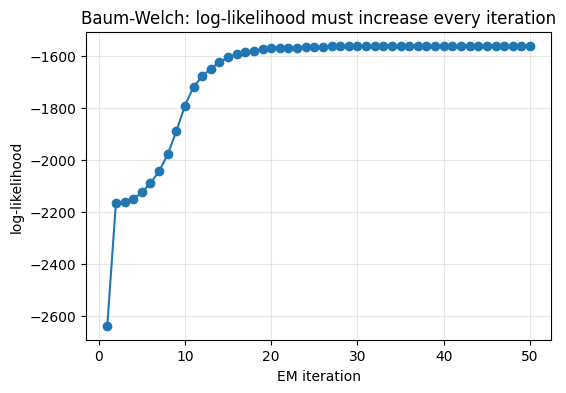

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(history) + 1), history, marker="o")
plt.xlabel("EM iteration")
plt.ylabel("log-likelihood")
plt.title("Baum-Welch: log-likelihood must increase every iteration")
plt.grid(alpha=0.3)
plt.show()


## 4. EM이 찾은 상태열과 실제 품사열 확인

In [30]:
# 예시 하나 자세히 보기
sample = test[0]
print("\n문장:", sample["sentence"])
pred = viterbi([vocab_idx[m] for m in sample["morphs"]], STATES, em_init, em_trans, em_emit)
for w, g, p in zip(sample["morphs"], sample["tags"], pred):
    print(f"  {w:6s}  정답={g:2s}  예측={p}")


문장: 그는 어제 늦게까지 일했다.
  그       정답=N   예측=1
  는       정답=J   예측=4
  어제      정답=M   예측=2
  늦       정답=A   예측=0
  게       정답=E   예측=7
  까지      정답=J   예측=2
  일       정답=N   예측=7
  하       정답=X   예측=2
  았       정답=E   예측=5
  다       정답=E   예측=2
  .       정답=S   예측=7
